In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
aqs = pd.read_csv("LA_AQS_2023.csv")

aqs.head()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
0,6,37,1103,68103,1,34.06659,-118.22688,WGS84,Ambient Min Temperature,24 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
1,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
2,6,37,1103,62201,1,34.06659,-118.22688,WGS84,Relative Humidity,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
3,6,37,1103,62101,1,34.06659,-118.22688,WGS84,Outdoor Temperature,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
4,6,37,1103,42603,1,34.06659,-118.22688,WGS84,Oxides of nitrogen (NOx),1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [3]:
o3 = aqs[
    (aqs["Parameter Name"] == "Ozone") &
    (aqs["Pollutant Standard"] == "Ozone 1-hour 1979")
].copy()

no2 = aqs[
    (aqs["Parameter Name"] == "Nitrogen dioxide (NO2)") &
    (aqs["Pollutant Standard"] == "NO2 1-hour 2010") &
    (aqs["POC"] == 1)
].copy()

# Convert ozone from ppm to ppb
o3["O3_ppb"] = o3["Arithmetic Mean"] * 1000

# NO2 is already in ppb
no2["NO2_ppb"] = no2["Arithmetic Mean"]

# Convert dates to datetime
o3["date"] = pd.to_datetime(o3["Date (Local)"])
no2["date"] = pd.to_datetime(no2["Date (Local)"])

o3.head()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source,O3_ppb,date
20,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart,31.708,2023-01-01
64,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart,15.792,2023-01-02
204,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart,25.000,2023-01-03
228,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart,20.500,2023-01-04
271,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart,27.375,2023-01-05


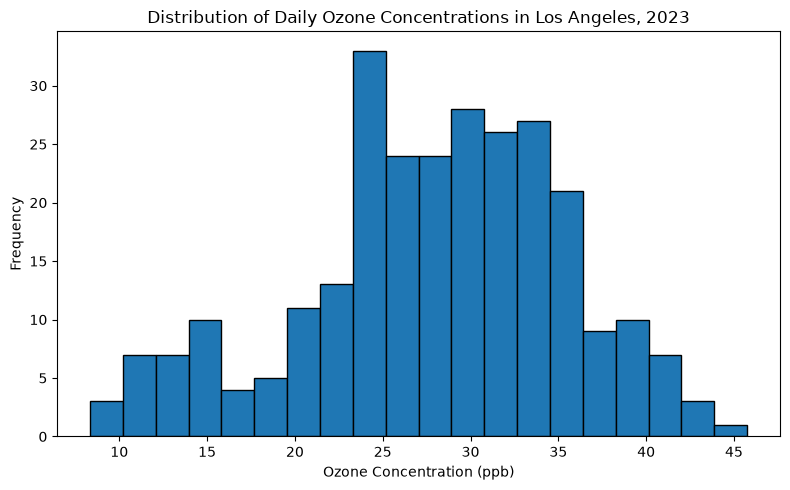

In [4]:
plt.figure(figsize=(8, 5))

plt.hist(o3["O3_ppb"], bins=20, edgecolor="black")

plt.xlabel("Ozone Concentration (ppb)")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Ozone Concentrations in Los Angeles, 2023")

plt.tight_layout()
plt.show()

The histogram shows that most daily ozone concentrations were concentrated in the lower-to-middle part of the observed range. Higher ozone concentrations occurred less frequently, giving the distribution a tail toward higher values.

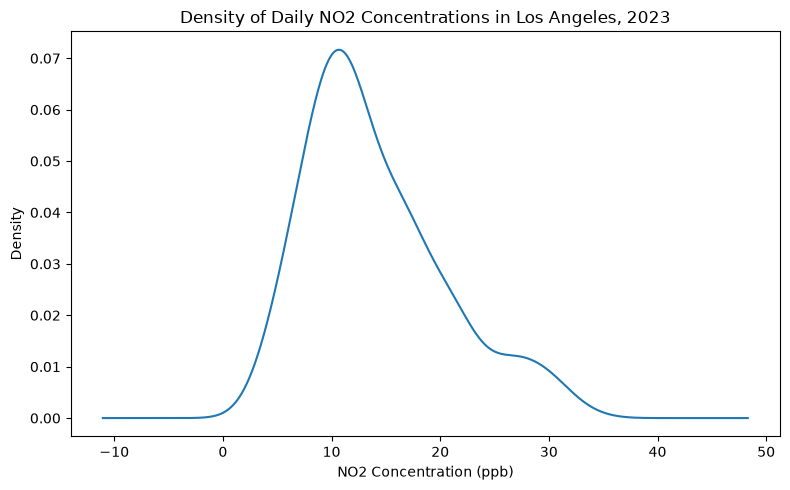

In [5]:
plt.figure(figsize=(8, 5))

no2["NO2_ppb"].plot.density()

plt.xlabel("NO2 Concentration (ppb)")
plt.ylabel("Density")
plt.title("Density of Daily NO2 Concentrations in Los Angeles, 2023")

plt.tight_layout()
plt.show()

The density plot shows where NO2 concentrations were most commonly found during 2023. The distribution is not perfectly symmetric, with fewer observations occurring at the higher NO2 concentrations.

In [6]:
o3_merge = o3[["date", "O3_ppb"]]
no2_merge = no2[["date", "NO2_ppb"]]

o3_no2 = o3_merge.merge(no2_merge, on="date")

o3_no2.head()

,date,O3_ppb,NO2_ppb
0,2023-01-01,31.708,4.550000
1,2023-01-02,15.792,15.416667
2,2023-01-03,25.000,11.608333
3,2023-01-04,20.500,14.486364
4,2023-01-05,27.375,11.008333


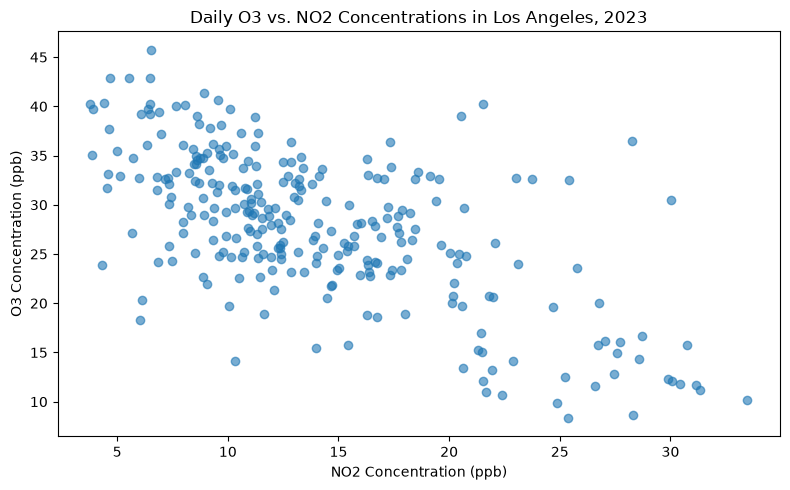

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(o3_no2["NO2_ppb"], o3_no2["O3_ppb"], alpha=0.6)

plt.xlabel("NO2 Concentration (ppb)")
plt.ylabel("O3 Concentration (ppb)")
plt.title("Daily O3 vs. NO2 Concentrations in Los Angeles, 2023")

plt.tight_layout()
plt.show()

The scatterplot shows the relationship between daily NO2 and ozone concentrations. The plot can be used to see whether days with higher NO2 concentrations tend to have higher or lower ozone concentrations.

In [8]:
# Keep only days with ozone greater than 35 ppb
high_o3 = o3[o3["O3_ppb"] > 35].copy()

# Get the month from each date
high_o3["month"] = high_o3["date"].dt.month

# Count number of high-ozone days in each month
days_per_month = high_o3.groupby("month").size()

# Make sure months with zero days are also included
days_per_month = days_per_month.reindex(range(1, 13), fill_value=0)

days_per_month

month
1      0
2      2
3      5
4     11
5      8
6      3
7      3
8      1
9     10
10     0
11     0
12     0
dtype: int64

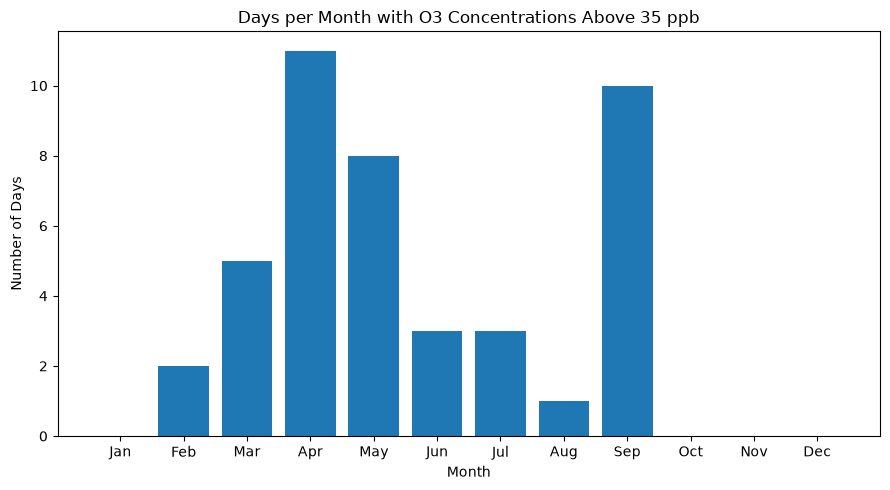

In [9]:
month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(9, 5))

plt.bar(month_names, days_per_month)

plt.xlabel("Month")
plt.ylabel("Number of Days")
plt.title("Days per Month with O3 Concentrations Above 35 ppb")

plt.tight_layout()
plt.show()

The bar chart shows how often ozone concentrations exceeded 35 ppb during each month of 2023. Higher counts during certain months indicate that elevated ozone concentrations were more common during those parts of the year.

In [10]:
co2 = pd.read_csv("ManuaLoa_CO2.csv")

co2.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99


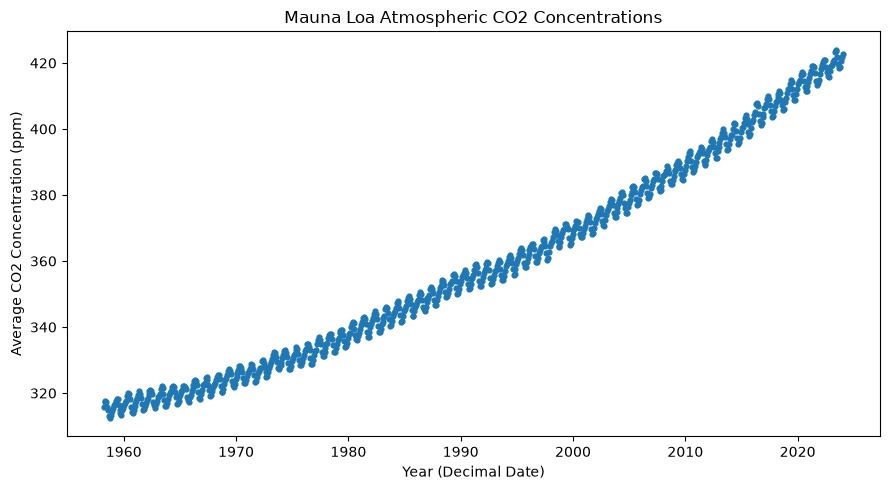

In [11]:
plt.figure(figsize=(9, 5))

plt.scatter(co2["decimal date"], co2["average"], s=12)

plt.xlabel("Year (Decimal Date)")
plt.ylabel("Average CO2 Concentration (ppm)")
plt.title("Mauna Loa Atmospheric CO2 Concentrations")

plt.tight_layout()
plt.show()

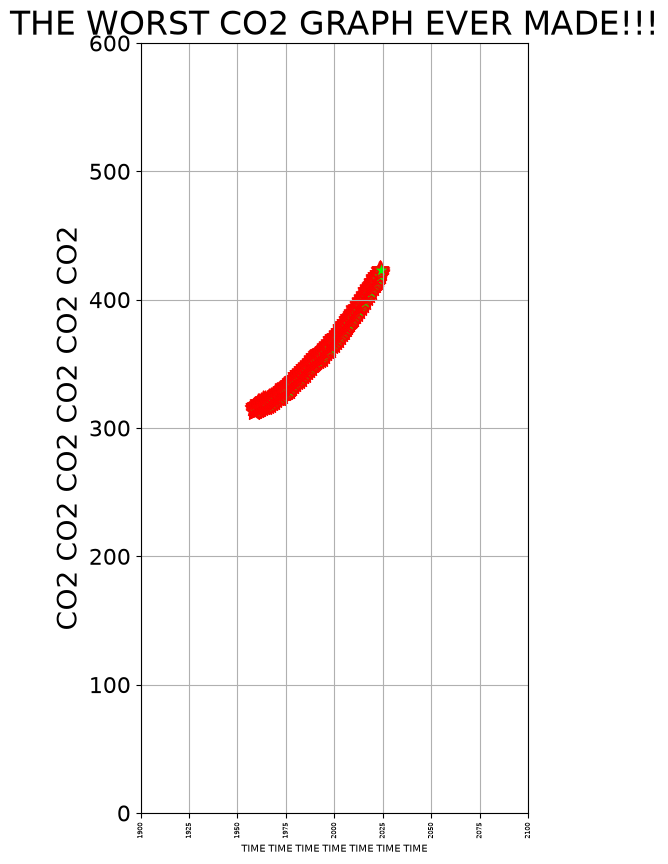

In [12]:
plt.figure(figsize=(5, 10))

plt.scatter(
    co2["decimal date"],
    co2["average"],
    s=150,
    marker="*",
    color="lime",
    edgecolor="red"
)

plt.xlabel(
    "TIME TIME TIME TIME TIME TIME TIME",
    fontsize=7
)

plt.ylabel(
    "CO2 CO2 CO2 CO2 CO2 CO2",
    fontsize=20
)

plt.title(
    "THE WORST CO2 GRAPH EVER MADE!!!",
    fontsize=24
)

plt.xticks(rotation=90, fontsize=5)
plt.yticks(fontsize=16)

plt.grid(True)

# Bad axis choices that still contain the data
plt.xlim(1900, 2100)
plt.ylim(0, 600)

plt.show()